In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv(r'C:\internship_oasis_online\OIBSIP\DataAnalytics-L1-EDARetailSales\data\cleaned_retail_sales_dataset.csv',parse_dates = ['order_date'])

#### importing the cleaned dataset 

In [3]:
df.shape

(4180, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4180 entries, 0 to 4179
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               4180 non-null   object        
 1   order_date             4180 non-null   datetime64[ns]
 2   customer_id            4180 non-null   object        
 3   customer_name          4180 non-null   object        
 4   age                    4180 non-null   float64       
 5   gender                 4180 non-null   object        
 6   region                 4180 non-null   object        
 7   city                   4180 non-null   object        
 8   product_category       4180 non-null   object        
 9   product_name           4180 non-null   object        
 10  quantity               4180 non-null   float64       
 11  unit_price             4180 non-null   float64       
 12  discount_pct           4180 non-null   float64       
 13  sal

In [5]:
df.select_dtypes(include='number').columns

Index(['age', 'quantity', 'unit_price', 'discount_pct', 'sales_amount',
       'profit', 'shipping_cost', 'customer_satisfaction', 'days_to_ship'],
      dtype='object')

#### selecting all numeric columns

In [6]:
numeric_df  = df.select_dtypes(include='number') 

#### creating numeric df for those numeric columns

In [7]:
numeric_df.shape

(4180, 9)

In [8]:
numeric_df.mean()

age                         35.103589
quantity                     5.483014
unit_price               10722.026727
discount_pct                 0.195541
sales_amount             55591.843254
profit                   10287.145811
shipping_cost               63.364813
customer_satisfaction        3.019030
days_to_ship                 5.632536
dtype: float64

#### mean

In [9]:
numeric_df.median()

age                        35.000
quantity                    5.000
unit_price               2248.255
discount_pct                0.200
sales_amount             9647.895
profit                   3169.875
shipping_cost              63.455
customer_satisfaction       3.000
days_to_ship                6.000
dtype: float64

#### median

In [10]:
numeric_df.mode()

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
0,35.0,5.0,103.75,0.0,10874.57,6.89,42.69,4.0,6.0
1,NaN,NaN,111.25,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,303.28,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,388.20,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,426.88,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,429.91,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,434.10,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,5472.78,NaN,NaN,NaN,NaN,NaN,NaN


#### mode

In [11]:
numeric_df.std()

age                          10.653746
quantity                      2.870908
unit_price                17423.523162
discount_pct                  0.121478
sales_amount             114964.423024
profit                    17862.703027
shipping_cost                18.315063
customer_satisfaction         1.413624
days_to_ship                  4.154747
dtype: float64

#### the standard deviation tells us :

results show particularly large variability in:

Unit price: 17423.52

Sales amount: 114964.42

Profit: 17862.70

In [12]:
mode_df = numeric_df.mode().apply(lambda col : col.dropna().tolist())
stats_df = pd.DataFrame({'mean' : numeric_df.mean() , 'median' : numeric_df.median() , 'std' : numeric_df.std() })
stats_df['mode'] = mode_df

In [13]:
stats_df.head(9)

,mean,median,std,mode
age,35.103589,35.000,10.653746,[35.0]
quantity,5.483014,5.000,2.870908,[5.0]
unit_price,10722.026727,2248.255,17423.523162,"[103.75, 111.25, 303.28, 388.2, 426.88, 429.91..."
discount_pct,0.195541,0.200,0.121478,[0.0]
sales_amount,55591.843254,9647.895,114964.423024,[10874.57]
profit,10287.145811,3169.875,17862.703027,[6.89]
shipping_cost,63.364813,63.455,18.315063,[42.69]
customer_satisfaction,3.019030,3.000,1.413624,[4.0]
days_to_ship,5.632536,6.000,4.154747,[6.0]


## Descriptive Statistics — Observations

- **Age:** The mean age is 35.10 years and the median is 35, indicating that the ages are relatively centered around 35.
- **Quantity:** The mean quantity is 5.48 while the median is 5, showing that customers typically purchase around 5 units per order.
- **Unit Price:** The mean unit price (10,722.03) is much higher than the median (2,248.26), with a high standard deviation (17,423.52), indicating substantial variability and a likely right-skewed distribution.
- **Sales Amount:** The mean sales amount (55,591.84) is considerably higher than the median (9,647.90), with a very high standard deviation (114,964.42), suggesting substantial variation in order values.
- **Profit:** The mean profit (10,287.15) is higher than the median (3,169.88), while the standard deviation (17,862.70) indicates considerable variation in profitability.
- **Shipping Cost:** The mean (63.36) and median (63.46) are very close, suggesting that shipping costs are relatively centered around this value.
- **Customer Satisfaction:** The mean satisfaction score is 3.02 and the median is 3, with a standard deviation of 1.41, indicating moderate variation in customer satisfaction.
- **Days to Ship:** The mean shipping time is 5.63 days and the median is 6 days, suggesting that orders typically take around 6 days to ship.

In [14]:
monthly_sales = df.groupby(df['order_date'].dt.month)['sales_amount'].sum()
monthly_sales.head()

order_date
1    13010784.33
2    16087286.96
3    18552353.55
4    20432103.57
5    24395339.77
Name: sales_amount, dtype: float64

In [15]:
monthly_sales = monthly_sales.reset_index()
monthly_sales.head()

,order_date,sales_amount
0,1,13010784.33
1,2,16087286.96
2,3,18552353.55
3,4,20432103.57
4,5,24395339.77


In [16]:
monthly_sales = monthly_sales.rename(columns = {'order_date' : 'months' , 'sales_amount' : 'total_sales_per_month'})

In [17]:
monthly_sales['months'] = monthly_sales['months'].astype(str)

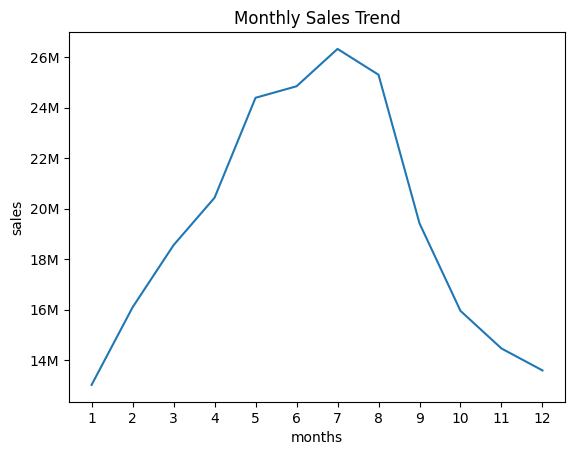

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure()
plt.plot(monthly_sales['months'] , monthly_sales['total_sales_per_month'])
plt.xlabel('months') 
plt.ylabel('sales') 
plt.title('Monthly Sales Trend')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
plt.show() 

### Observation

Monthly sales show noticeable fluctuations throughout the year, with some months generating substantially higher sales than others. Sales generally increase during the middle of the year, reaching their highest levels in the later months before declining again. This indicates that sales performance varies considerably from month to month.

In [19]:
quarter_sales = df.groupby(df['order_date'].dt.quarter)['sales_amount'].sum().reset_index()
quarter_sales

,order_date,sales_amount
0,1,47650424.84
1,2,69678442.19
2,3,71057611.34
3,4,43987426.43


In [20]:
quarter_sales = quarter_sales.rename(columns = {'order_date' : 'quarter' , 'sales_amount' : 'sum_sales_per_quarter'})
quarter_sales

,quarter,sum_sales_per_quarter
0,1,47650424.84
1,2,69678442.19
2,3,71057611.34
3,4,43987426.43


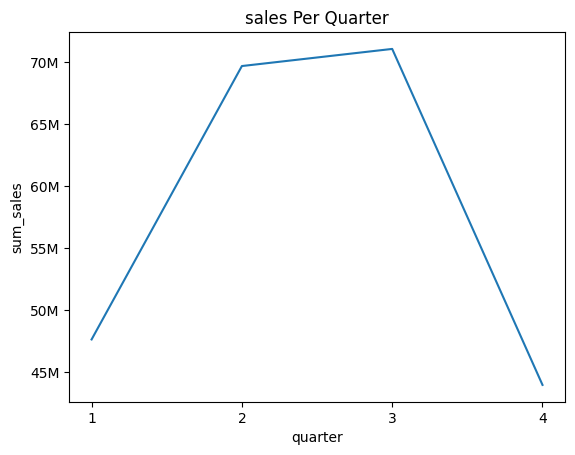

In [29]:
from matplotlib.ticker import FuncFormatter
plt.figure()
plt.plot(quarter_sales['quarter'] , quarter_sales['sum_sales_per_quarter'])
plt.xlabel('quarter')
plt.ylabel('sum_sales')
plt.title('sales Per Quarter')
plt.xticks([1, 2, 3, 4])
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M'))
plt.show()

### Observation

Sales increased from Q1 to Q2 and reached their highest level in Q3, with approximately **71 million** in sales. Sales then dropped significantly in Q4 to approximately **44 million**, making Q4 the lowest-performing quarter. Overall, the chart shows strong growth during the first three quarters followed by a sharp decline in the final quarter.


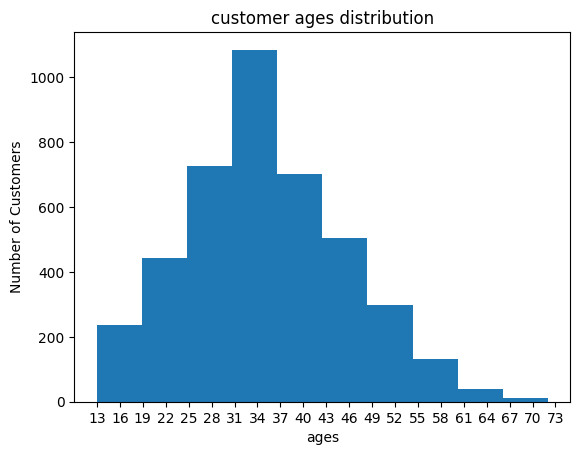

In [23]:
plt.figure()
plt.hist(df['age'])
plt.xlabel('ages')
plt.ylabel('Number of Customers')
plt.title('customer ages distribution')
plt.xticks(range(13, 74, 3))
plt.show()

#### Observation

The customer age distribution shows that the 30–37 age group has the highest number of customers. The customers' ages range from approximately 13 to 72 years, indicating a relatively broad age distribution.

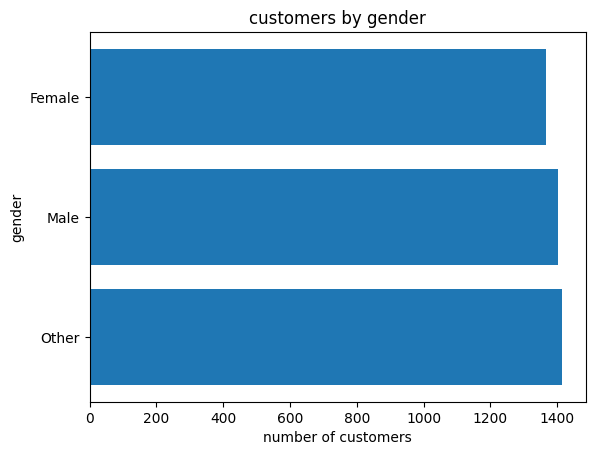

In [28]:
plt.figure()
plt.barh(df['gender'].value_counts().index, df['gender'].value_counts().values)
plt.xlabel('number of customers')
plt.ylabel('gender')
plt.title('customers by gender')
plt.show()

####  Observation

The gender distribution is relatively balanced across the three categories. **Other** has the highest number of customers with **1,414**, followed by **Male** with **1,401** and **Female** with **1,365**. The differences between the categories are relatively small.


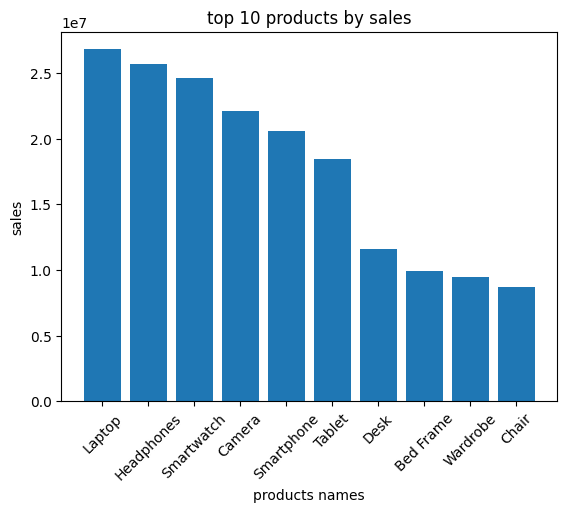

In [25]:
x = df.groupby(df['product_name'])['sales_amount'].sum().sort_values(ascending=False).head(10)
plt.figure()
plt.bar(x.index, x.values)
plt.xlabel('products names')
plt.ylabel('sales')
plt.title('top 10 products by sales')
plt.xticks(rotation = 45)
plt.show()

#### Observation

The chart shows the 10 products with the highest total sales in the dataset. The sales amounts vary considerably among these products, with the laptop category generating the highest total sales.

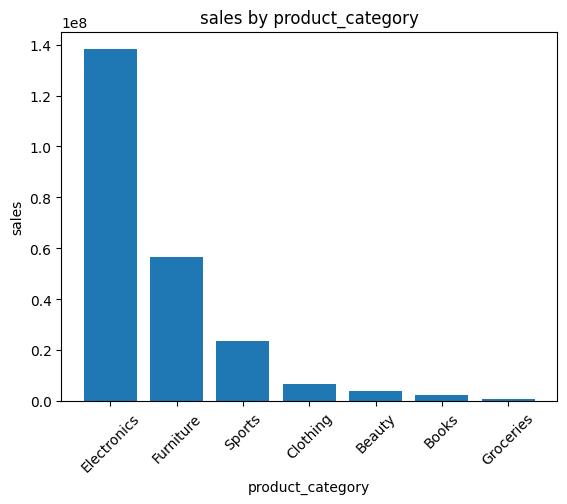

In [26]:
x = df.groupby(df['product_category'])['sales_amount'].sum().sort_values(ascending = False)
plt.figure()
plt.bar(x.index, x.values)
plt.xlabel('product_category')
plt.ylabel('sales')
plt.title('sales by product_category')
plt.xticks(rotation = 45)
plt.show()

#### Observation

The revenue distribution varies significantly across product categories. Electronics generated the highest revenue at approximately 138.18 million, followed by Furniture at 56.69 million and Sports at 23.75 million. Groceries generated the lowest revenue at approximately 0.87 million. Overall, Electronics contributed substantially more revenue than the other categories.

In [27]:
sns.heatmap(corr_matrix, annot=True)
plt.title('Correlation Heatmap of Numerical Variables')
plt.xticks(rotation = 80)

NameError: name 'sns' is not defined

#### Observation

The correlation heatmap shows that sales amount and profit have a very strong positive correlation (0.892). There is also a strong positive correlation between unit price and sales amount (0.811), while unit price and profit show a moderately strong positive correlation (0.697). Most of the other numerical variables have correlations close to zero, indicating weak linear relationships between them.

In [ ]:
plt.figure(figsize=(8, 6))

sns.boxplot(x='customer_satisfaction', y='sales_amount', data=df)

plt.xlabel('Customer Satisfaction')
plt.ylabel('Sales Amount')
plt.title('Sales Amount by Customer Satisfaction')

plt.show()

#### Observation

The box plot shows that the distribution of sales amounts is relatively similar across the different customer satisfaction ratings. There is no clear increasing or decreasing pattern in sales amount as customer satisfaction changes. The chart also contains many high-value outliers across all satisfaction levels, indicating that some orders have exceptionally high sales amounts. Overall, customer satisfaction does not appear to have a strong visible relationship with individual sales amount in this dataset.

# Conclusion

The exploratory data analysis revealed several important patterns in the retail sales dataset. Sales were strongest in **Q3**, while **Q4 showed a significant decline**. **Electronics** generated the highest revenue among all product categories, while some products contributed considerably more sales than others. The customer base was relatively balanced across gender categories, with the **30–37 age group** representing the largest age range. The correlation analysis also showed a strong relationship between **sales amount and profit**, while customer satisfaction did not show a clear relationship with individual sales amount.

### Business Recommendations

1. **Focus inventory and marketing on high-performing products and categories.**
   Since Electronics generated the highest revenue and a small group of products accounts for a large share of sales, the business should prioritize stock availability, promotions, and marketing campaigns for these high-performing products.

2. **Investigate the Q4 sales decline and strengthen seasonal campaigns.**
   Since Q4 recorded the lowest quarterly sales, the business should analyze the causes of the decline and introduce targeted promotions, discounts, or seasonal campaigns before and during Q4 to improve sales performance.

3. **Use the 30–37 age group as an important customer segment.**
   As this age group represents the largest portion of customers, the business could develop targeted marketing campaigns and product offers that are relevant to their purchasing behavior.

4. **Monitor profitability alongside sales revenue.**
   Because sales amount and profit have a very strong positive correlation, management should track both metrics when evaluating products and categories rather than focusing only on revenue.

5. **Improve customer experience independently from sales targeting.**
   Since customer satisfaction does not show a clear relationship with individual sales amount, the business should monitor satisfaction separately and identify factors such as delivery time, product quality, returns, and service that may influence customer experience.
